## Linnerud Dataset, Regression Model Project
#### The Orgin of Dataset

This dataset was collected by Dr John Linnerud in 1960, from 20 middle aged men, the main gaol was to study the relationship between physical exercise and physiological measurement.

#### Objective of the Project
The main purpose of this dataset is to know how does pyhical fitness line chins,situps and jumps relate to the body meausument which are, body weight, waist size and heart rate (pulse).
Using Liner Regression Model aim is to predict body measurement based on exercise perfomance and analyze how exercies impact overall physical health of individual.

#### Methodolody
To achieve this project the following step will be undertaken
 * Exploratory Data Analysis (EDA)
 * Model building
 * Model evaluation
 * Model deployment using a web application
 * Communicating insights through a technical report


#### A. Exploratory Data Analysis (EDA)
In this step we are going to examine and understand linnerud datasets by using statistical and visualization to identify its pattern and trend, characteristics, relationship between variable and detecting outlier before modeling

By considering the following steps


#### 1 Step: Understanding  dataset
Lnnerud dataset is included in scikit-learn, and contain exercise performance and body measurement of 20 men, where by it show how the relationship between physical fitness and body condition.
This dataset also combine exercise variable like (chins,situps an jumps) as a feature and Physiological Variables like (Target,waist and pulse) as target

##### Difinition of exerciese variable
In This Dataset there are three input (featues) which describe how fit and strong person is, the three variable is measured by number (counts) of exercice person can do
* Chins (pull-ups) - upper-body strength exercise
* Situps - abdominal muscles exerciese
* Jumps  - vertical jump test for lower body strength and power

##### Difinition of Physiological Variables
In This Dataset there are three output (targets) which describe health and body condition.
* **Weight** - body weight of individual

This target is measured by Pounds (lbs) a unit of weight, where it showing how exercise performance influance body mass of individual
* **Waist** - Central body fat distribution

This target is measured by (inches) where, it showing how fittness level may correlate with body fat distribution
* **Pulse** - Number of heart beat per min while person is at rest

This target is measured by (bpm), where by it showing how the physical fitness relate to cardiovascular health.

#### 2 Step: Importing Libaries and Load dataset
Before working with the linnerud dataset, we need to import the necessary **Python libraries** for Exploratory data analysis and Machine learning Modeling. Each library has a specific role

In [1]:
# Import libraries for data handling and analysis
import pandas as pd  # For data creating and handling tabaular data
import numpy as np   # For handling numerical operations and modeling data

# Import library for visualization
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns    # For advanced visualization and customizing chart
sns.set_theme(style = "darkgrid") # for setting theme and make graph more professional

# Import library for machine learning and model evaluation
from sklearn.datasets import load_linnerud   # To load the Linnerud dataset
from sklearn.model_selection import train_test_split # for splitting data into training and test
from sklearn.metrics import mean_squared_error, r2_score # for evaluating model

# Import and load linnerud datasets form sklearn
from sklearn.linear_model import LinearRegression  # For EDA and Regression Model

print(" All Libaries are imported successfully")

 All Libaries are imported successfully


#### 3 Step: Initail exploration
In this step we are going to naming and understanding Linnerud dataset by identify featues and targets variables

##### Initialization of Dataset

In [2]:
# namig dataset by features and targates
data = load_linnerud()
# Cheking for the Featues names by for loop
print(f"This are the Faatures of Linnerud dataset")
for Features in data.feature_names:
    print(Features)

This are the Faatures of Linnerud dataset
Chins
Situps
Jumps


In [3]:
# namig dataset by features and targates
data = load_linnerud()
# Cheking for the Targets names by for loop
print(f"This are the Targets of Linnerud dataset")
for Targets in data.target_names:
    print(Targets)

This are the Targets of Linnerud dataset
Weight
Waist
Pulse


In [4]:
# Here we are going to naming featurea and target x and y respectively and concert to dataframe
# Converting Features to DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)

# Converting Targets to DataFrame
y = pd.DataFrame(data.target, columns=data.target_names)

# Converting  Features and Targets and naming as df
df = pd.concat([X, y], axis=1) # the axis = 1 represent join varaiables by columns ( remember 0 is for rows and 1 is for column)

# Print columns and rows in dataset
df.head()

,Chins,Situps,Jumps,Weight,Waist,Pulse
0,5.0,162.0,60.0,191.0,36.0,50.0
1,2.0,110.0,60.0,189.0,37.0,52.0
2,12.0,101.0,101.0,193.0,38.0,58.0
3,12.0,105.0,37.0,162.0,35.0,62.0
4,13.0,155.0,58.0,189.0,35.0,46.0


##### Understanding of Dataset

In [5]:
# Understanding dataset by pandas for Data analysis
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Chins   20 non-null     float64
 1   Situps  20 non-null     float64
 2   Jumps   20 non-null     float64
 3   Weight  20 non-null     float64
 4   Waist   20 non-null     float64
 5   Pulse   20 non-null     float64
dtypes: float64(6)
memory usage: 1.1 KB


**Insight from initial Exploration based on EDA**

Linnerud dataset Contain 20 Records of middle aged men where by each records is unique (no duplicates) also it has three feature variables and three target variables, where by
* **Feature variables** are input variables (independent) which represent pyhisical fitness performance of each individual
* **Target variables** are output variables (dependent) which represent physiological measurements of each individual

Also all variables are stored as number and all culumns are non mull

In [6]:
# Understanding dataset by numpy for regression analysis
data = load_linnerud()
data

{'data': array([[  5., 162.,  60.],
        [  2., 110.,  60.],
        [ 12., 101., 101.],
        [ 12., 105.,  37.],
        [ 13., 155.,  58.],
        [  4., 101.,  42.],
        [  8., 101.,  38.],
        [  6., 125.,  40.],
        [ 15., 200.,  40.],
        [ 17., 251., 250.],
        [ 17., 120.,  38.],
        [ 13., 210., 115.],
        [ 14., 215., 105.],
        [  1.,  50.,  50.],
        [  6.,  70.,  31.],
        [ 12., 210., 120.],
        [  4.,  60.,  25.],
        [ 11., 230.,  80.],
        [ 15., 225.,  73.],
        [  2., 110.,  43.]]),
 'feature_names': ['Chins', 'Situps', 'Jumps'],
 'target': array([[191.,  36.,  50.],
        [189.,  37.,  52.],
        [193.,  38.,  58.],
        [162.,  35.,  62.],
        [189.,  35.,  46.],
        [182.,  36.,  56.],
        [211.,  38.,  56.],
        [167.,  34.,  60.],
        [176.,  31.,  74.],
        [154.,  33.,  56.],
        [169.,  34.,  50.],
        [166.,  33.,  52.],
        [154.,  34.,  64.],
        

**Insight from initial Exploration based on Regression Model**

The shape of linnerud datasets are (20,3) for feature and (20,3) and target
where by it has 20 records and three dependent variable (target) which are 

**Weight** - body mass of individual

**Waist** - central body fat distribution

**Pulse** - number of heart beat per min while individual is at rest

Regression Model involve predicting a continuous numeric output based on input variables and in linnerud dataset target variable ( weight, waist and pulse) are continuous numeric on their measurement which are suitable for prediction.

Also in regression model we are going to look how the changes of fauture variables ( chins, situps and jumps) will affect the target variables

**Important Note**

Based on linnerud dataset it has three output (target) which refer as **Multi Output Regression** where by a single model predicts multiple continuous outputs simultaneously

#### 4 Step: Data Preprocessing
In this step we are going to cleaning and organizing linnerud datasets to improve its quality and making suitable for Visualization analysis and modeling

In [7]:
# checking for missing value by for loop
for column in df.columns:
    if df[column].isnull().sum() > 0:
        print(f"The colunms {column} has {df[column].isnull().sum()} missing value")
    else:
        print(f"There is no Missing value in {column} column")

There is no Missing value in Chins column
There is no Missing value in Situps column
There is no Missing value in Jumps column
There is no Missing value in Weight column
There is no Missing value in Waist column
There is no Missing value in Pulse column


In [8]:
# checking for duplicate value by condition
if df.duplicated().sum() >0:
    print(f"The Total Duplicate are {df.duplicated().sum()}")
else:
    print("All record are unique.")

All record are unique.


**Insight form data preprocessing**

There is no missing value in linnerud daraset and all record are unique (no duplicate)


#### 5 Step: Feature Engineering
In this process we are going to to creating feature variable in order to improve model performance, but we will proceed with this process in modeling


#### 6 Step: Statistical Unvariate Analysis
Here we are going to analyse one by one variable in order to understanding its characteristic and how its distributed by using statistical summury, histogram and box plot for determine outliaer

In [9]:
# Statistical summary
df.describe()

,Chins,Situps,Jumps,Weight,Waist,Pulse
count,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000
mean,9.450000,145.550000,70.30000,178.600000,35.400000,56.100000
std,5.286278,62.566575,51.27747,24.690505,3.201973,7.210373
min,1.000000,50.000000,25.00000,138.000000,31.000000,46.000000
25%,4.750000,101.000000,39.50000,160.750000,33.000000,51.500000
50%,11.500000,122.500000,54.00000,176.000000,35.000000,55.000000
75%,13.250000,210.000000,85.25000,191.500000,37.000000,60.500000
max,17.000000,251.000000,250.00000,247.000000,46.000000,74.000000


**Insight about summary statistics**

From this statistical dataset we see that
The group has average fitness levels overall, exercise ability varies widely between individuals and body measurements vary less than exercise performance.

Since the dataset is very small exercise variables such as Situps and Jumps indicate higher variability some individuals show exceptionally high exercise performance while Waist and Pulse measurements are more consistent across individual.


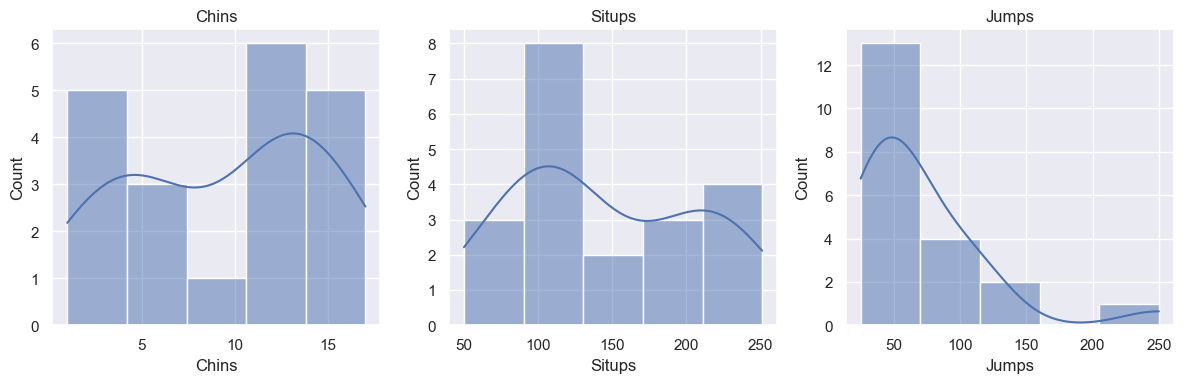

In [10]:
# creating histogram for the feature variable in one plot to see how data is distributed
fig, axes = plt.subplots(1, 3, figsize=(12,4))

# Histogram for Chins
sns.histplot(df["Chins"], bins=5, kde=True, ax=axes[0])
axes[0].set_title("Chins")

# Histogram for Situps
sns.histplot(df["Situps"], bins=5, kde=True, ax=axes[1])
axes[1].set_title("Situps")

# Histogram for Jumps
sns.histplot(df["Jumps"], bins=5, kde=True, ax=axes[2])
axes[2].set_title("Jumps")

plt.tight_layout()
plt.show()

**Insigh for Histrogram**

From the histograms Exercise performance (Chins, Situps and Jumps) show variation among participants

Situps and Jumps have wider distributions, indicating larger differences in physical exercise.
Some high-performing individuals create right-skewed distributions, especially in Jumps.

Chins are more moderately distributed, suggesting less extreme variation in upper-body strength.


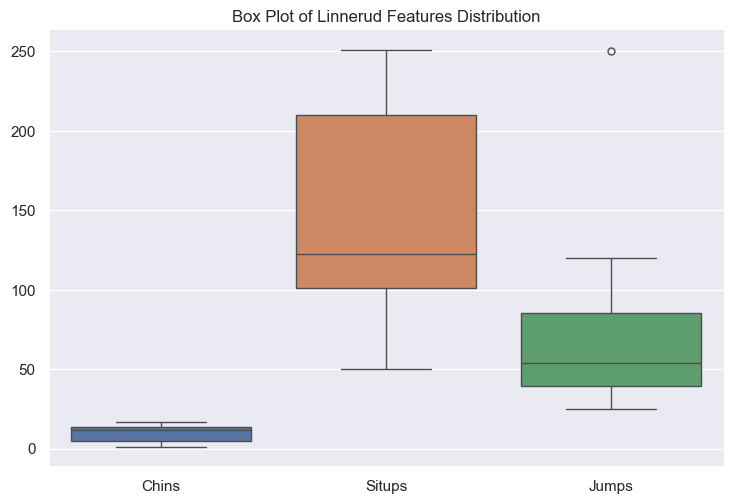

In [11]:
# creating dictionaries for the feature variable
df_box = pd.DataFrame({
    "Chins": df["Chins"],
    "Situps": df["Situps"],
    "Jumps": df["Jumps"]
})

# Create boxplots using catplot
sns.catplot(
    data=df_box,
    kind="box",
    height=5,
    aspect=1.5
)

plt.title("Box Plot of Linnerud Features Distribution")
plt.show()

**Insight for Box plot**

Chins insight

The median number of chins is around the Q3 of the distribution, indicating that The distribution is negatively skewed.
Most individuals have similar upper-body strength levels, with mostly performing moderate to fewer chin-ups.

Situps insight

The spread of the box is larger compared to chins, indicating greater variability in sit-up performance.
The median line is neary to Q1 indicating The distribution is positively skewed (right-skewed), showing that many participants perform a moderate to high number of sit-ups.

Jumps insight

The distribution of jumps is moderately spread, The median indicates that most participants perform a moderate number of jumps.
The whiskers may extend slightly higher, suggesting a few participants with higher lower-body endurance.


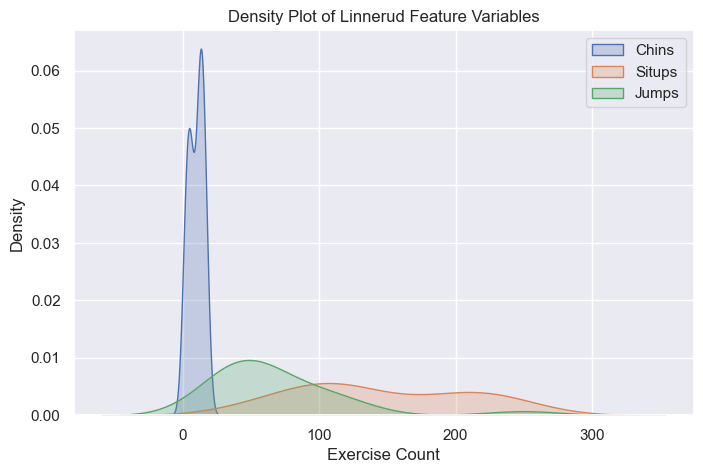

In [12]:
# Density plot
# Create one figure
plt.figure(figsize=(8,5))

# Plot density for each feature
sns.kdeplot(df["Chins"], fill=True, label="Chins")
sns.kdeplot(df["Situps"], fill=True, label="Situps")
sns.kdeplot(df["Jumps"], fill=True, label="Jumps")

# Add title and labels
plt.title("Density Plot of Linnerud Feature Variables")
plt.xlabel("Exercise Count")
plt.ylabel("Density")
plt.legend()
plt.show()

**Insight for Density plot**

Chins insight

The density curve for chins typically peaks around the middle values, indicating that most participants perform a moderate number of chin-ups.
The curve is relatively narrow, meaning the values are fairly concentrated.

Situps insight

The density curve for situps tends to be wider, showing greater spread in the data.
The peak occurs around the moderate range, but the distribution may extend toward higher values and this suggests differ significantly in abdominal exercise, with some individuals performing much higher numbers of sit-ups than others.

Jumps insight

The density plot for jumps usually shows a moderate spread with a clear central peak.
Most participants fall within a middle range of jump counts and the distribution may slightly extend toward higher values.




#### 7 Step: Bivariate Analysis
Now we are going to use scatter plot and regression plot to study the relationship between our features and target in datasets

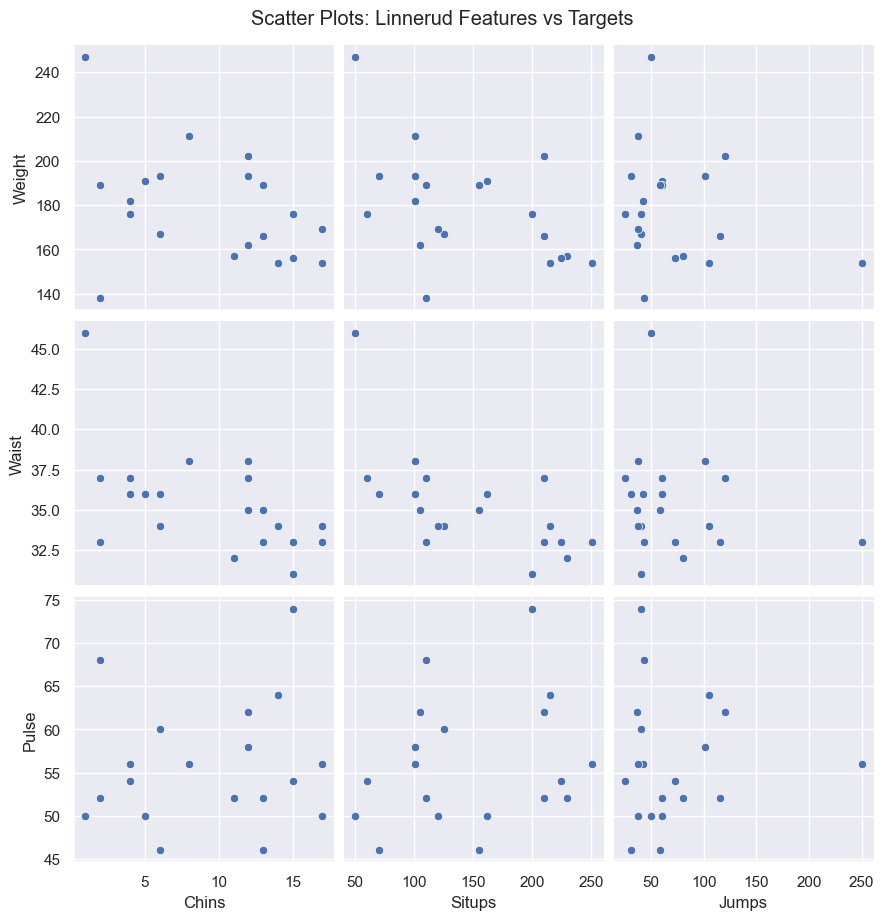

In [13]:
# plot scatter plot
sns.pairplot(df, x_vars=data.feature_names, y_vars=data.target_names, height=3, aspect=1)
plt.suptitle("Scatter Plots: Linnerud Features vs Targets", y=1.02)
plt.show()

**Insight for scatter plot**

Chins vs Physiological Variables

The scatter plot may show a slight negative relationship between Chins and Waist
Participants who perform more chin-ups may tend to have smaller waist measurements, also the points are somewhat scattered, indicating the relationship is not very strong.

Situps vs Physiological Variables

Situps may show a moderate relationship with Waist, Individuals who perform more sit-ups may have lower waist sizes also the scatter points spread widely, suggesting variability among individuals.

Jumps vs Physiological Variables

The scatter plot for Jumps vs Pulse or Weight may show weak relationships, The data points are more dispersed, indicating that jumping performance may not strongly predict these physiological measures.

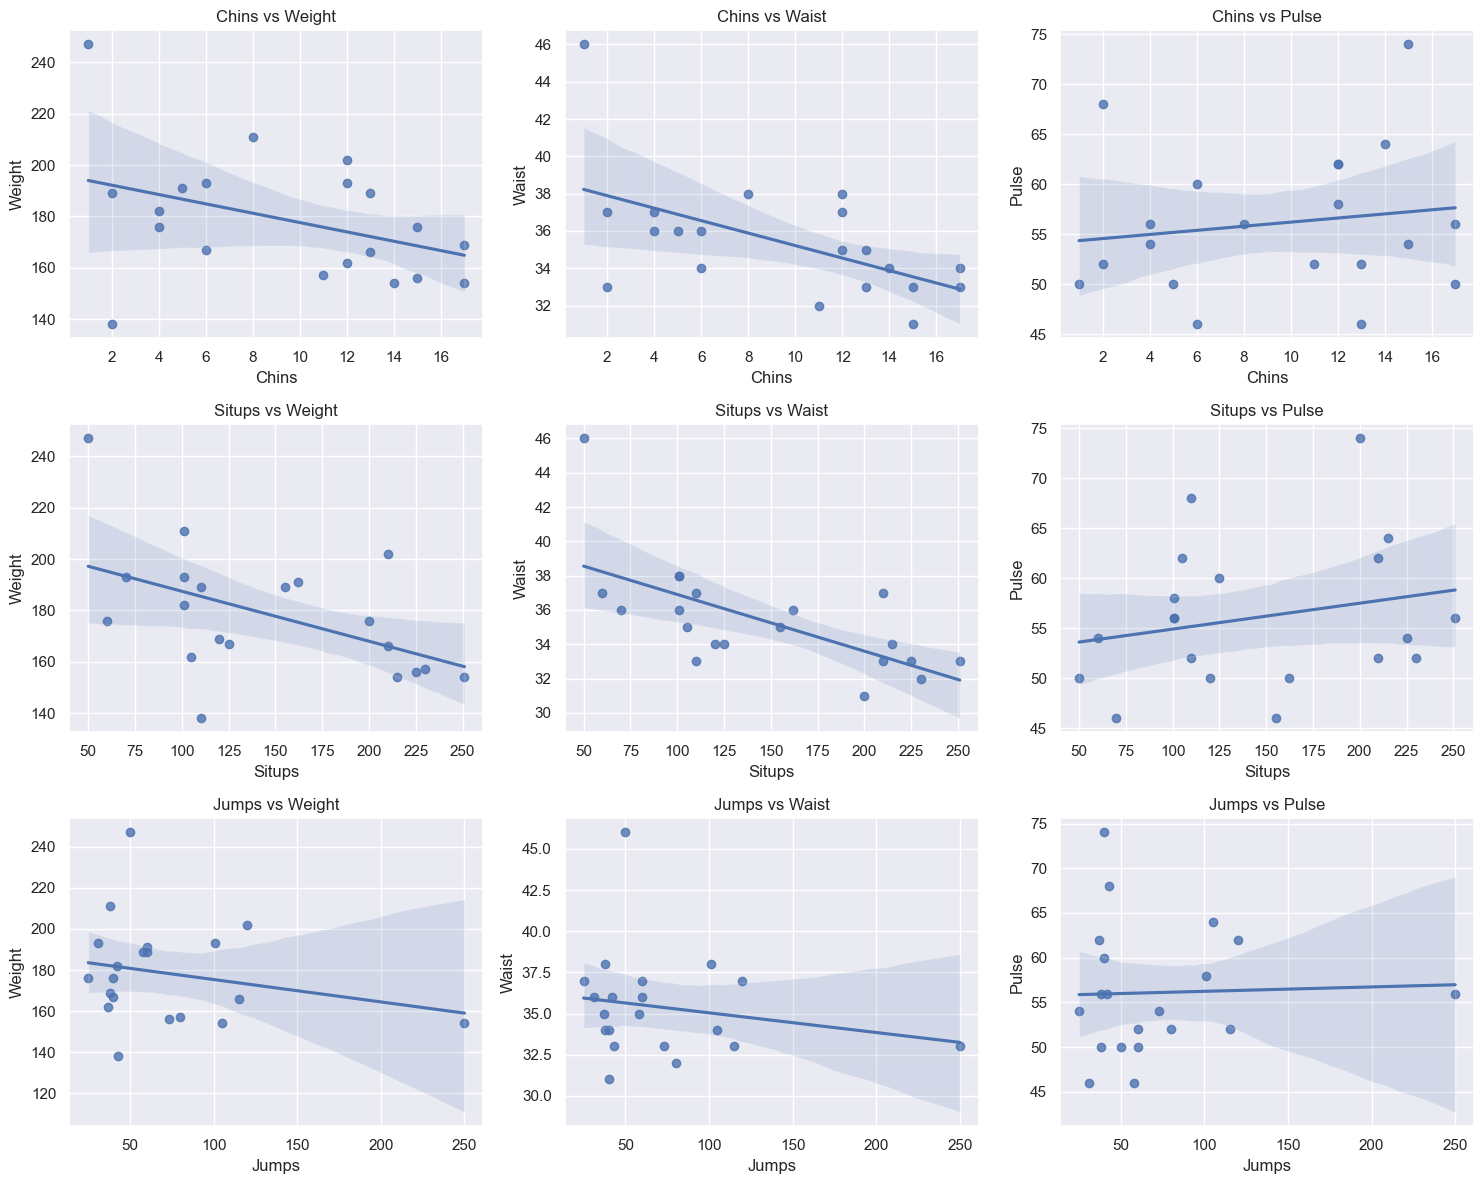

In [24]:
#Regression plot
plt.figure(figsize=(15,12))
# Chins vs Weight
plt.subplot(3,3,1)
sns.regplot(x="Chins", y="Weight", data=df)
plt.title("Chins vs Weight")

# Chins vs Waist
plt.subplot(3,3,2)
sns.regplot(x="Chins", y="Waist", data=df)
plt.title("Chins vs Waist")

# Chins vs Pulse
plt.subplot(3,3,3)
sns.regplot(x="Chins", y="Pulse", data=df)
plt.title("Chins vs Pulse")

# Situps vs Weight
plt.subplot(3,3,4)
sns.regplot(x="Situps", y="Weight", data=df)
plt.title("Situps vs Weight")

# Situps vs Waist
plt.subplot(3,3,5)
sns.regplot(x="Situps", y="Waist", data=df)
plt.title("Situps vs Waist")

# Situps vs Pulse
plt.subplot(3,3,6)
sns.regplot(x="Situps", y="Pulse", data=df)
plt.title("Situps vs Pulse")

# Jumps vs Weight
plt.subplot(3,3,7)
sns.regplot(x="Jumps", y="Weight", data=df)
plt.title("Jumps vs Weight")

# Jumps vs Waist
plt.subplot(3,3,8)
sns.regplot(x="Jumps", y="Waist", data=df)
plt.title("Jumps vs Waist")

# Jumps vs Pulse
plt.subplot(3,3,9)
sns.regplot(x="Jumps", y="Pulse", data=df)
plt.title("Jumps vs Pulse")

plt.tight_layout()
plt.show()

**Insight for regression plot**

A regression plot combines a scatter plot of the data points with a best fit regression line that shows the overall trend between the variables.

In this analysis, regression plots were used to compare the exercise features (Chins, Situps, Jumps) with the physiological target variables (Weight, Waist, Pulse). Each point in the plot represents one participant in the dataset, while the regression line shows the estimated relationship between exercise performance and body measurements, help to kmow how the target variable changes when the feature variable changes.

By observing the direction of the regression line we can see the relationship between features and targets mostly has negative relationship but not strong (mild) becouse of few observation records for example situps and waist is negative relationship, participant who doing more situps have small waist size.


#### 7 Step: Multivariate Analysis
This is the relatioship between more than two variable and now we are goinng to use heat map to see how all variables relate to one another

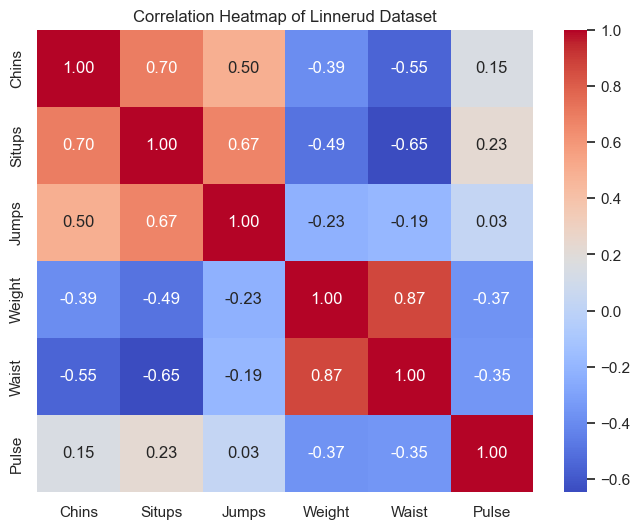

In [15]:
# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Linnerud Dataset")
plt.show()

**Insight for correlation Heatmap**


From the heatmap, we observe the strength and direction of relationships between both exercise and body measurements variables. Positive correlations indicate that two variables increase together, while negative correlations indicate that one variable decreases as the other increases as we can see individual who perform more situps has small weight and waist size, also individual who has the largest weight has greater waist size.

Another variables has moderete correlation becouse our Observation records are very small make difficult for the variable to provide strong relatioship.

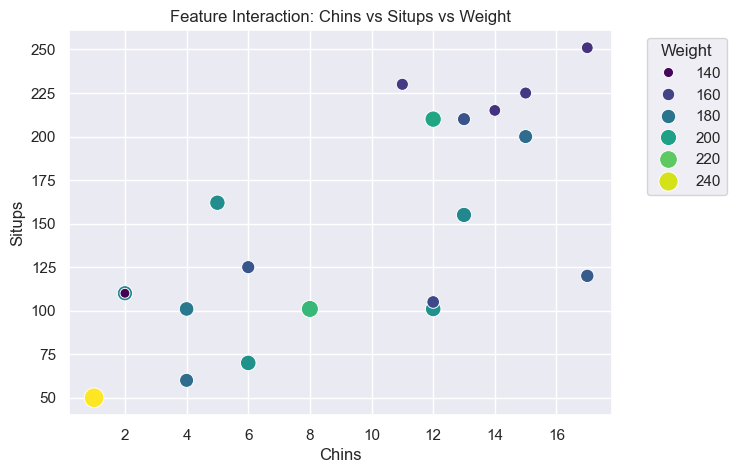

In [16]:
# Interaction plot for Chins vs Situps colored by Weight
plt.figure(figsize=(7,5))
sns.scatterplot(x="Chins", y="Situps", hue="Weight", palette="viridis", size="Weight", sizes=(50,200), data=df)
plt.title("Feature Interaction: Chins vs Situps vs Weight")
plt.xlabel("Chins")
plt.ylabel("Situps")
plt.legend(title="Weight", bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

**Insight of Feature Interaction**

Feature interaction plots show how the effect of one exercise feature on a physiological measurement changes depending on another exercise feature. In the Linnerud dataset, interactions are generally mild (present but not very strong), suggesting that exercise features mostly influence targets independently, but some minor interactions may exist example sit-ups may affect waist differently at different levels of chins.

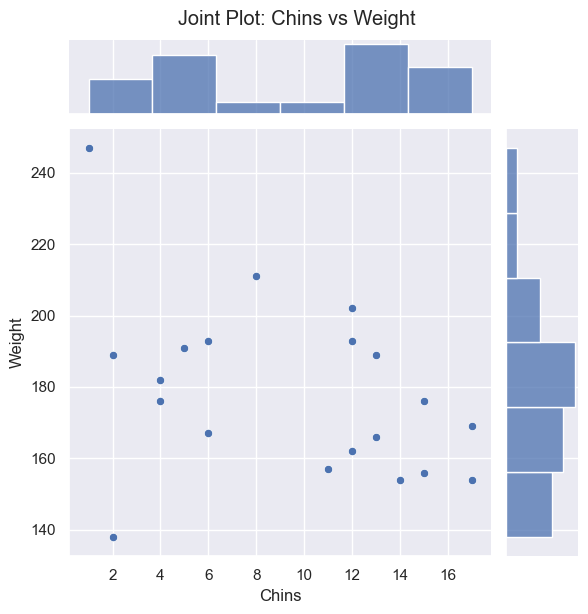

In [17]:
# Joint plot for  Chins vs Weight
sns.jointplot(
    x="Chins", 
    y="Weight", 
    data=df, 
    kind="scatter",  # "scatter", "reg", "kde", "hex"
    height=6
)

plt.suptitle("Joint Plot: Chins vs Weight", y=1.02)
plt.show()

**Insight for Joint Plont**

A joint plot visualizes the relationship between two variables and their distributions at the same time. In the Linnerud dataset, it helps understand how exercise features (Chins, Situps, Jumps) relate to physiological targets (Weight, Waist, Pulse) while also showing the spread of each variable.
And in our joint chart we see there is no relationship between chins and weight, the distribution of weight is negative skewness having many lowest value and data the distribution of chins is nearly normal.

#### General Conclution

The Linnerud dataset consists of 20 observations with 3 exercise features (Chins, Situps, Jumps) and 3 body measurement targets (Weight, Waist, Pulse). All variables are numeric and continuous. 

No missing values or extreme outliers were detected also Correlation analysis shows moderate relationships between features and targets, and scatter plots indicate roughly linear trends.

Feature distributions are mostly symmetric with slight skewness in exercise counts (the dataset is mostly balanced around the center, but the tail slightly stretches to one side) and Multicollinearity is low means that......

* Features in the dataset (Chins, Situps, Jumps) are not strongly correlated with each other since there is small observation.
* Each feature provides unique information for predicting the targets (Weight, Waist, Pulse).
* Linear regression coefficients will be stable and interpretable (the features don’t duplicate each other, so the model can learn their separate effects reliably)

Overall, the dataset is clean and well suited for a linear regression model without extensive preprocessing.

#### B. Data Preparation for Modeling
After completing Exploratory Data Analysis (EDA), the next step is data preparation for modeling.

This step we are going to ensures our data is clean, structured, and suitable for a Linear Regression.

By doing the following steps 

##### Step 1: Separate Features and Target
We have already conduct this step of separating variable in EDA now we recall our variables and naming

Features (independent variable) (X) - predictors (exercise counts: Chins, Situps, Jumps)

Target (dependent variable) (y) - response (body measurements: Weight, Waist, Pulse)


In [18]:
# Features (input)
X = pd.DataFrame(data.data, columns=data.feature_names)
# Targets (output)
y = pd.DataFrame(data.target, columns=data.target_names)

##### Step 2: Handle Missing Values
This very crucial process in Machine learning modelng, where by we apply extensive preprocessing to handle the missing value, but in Linnerud dataset there is no Missing value as shown in a code below

In [19]:
# Cheking for missing value
print(X.isnull().sum())
print(y.isnull().sum())

Chins     0
Situps    0
Jumps     0
dtype: int64
Weight    0
Waist     0
Pulse     0
dtype: int64


##### Step 3: Split Data into Train and Test
Here we split all features and targets into train/test without dropping anything, because each feature contributes to the regression model.
No need to drop columns in this step because the dataset is small and already split into features and targets.

In [25]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# 20% for testing
# random_state=42 - reproducible split
"""
   here we train the model  with our datasets by 80% and testing if model can predict new unseen data by 20%
   also use seed (random_state = 42) to get the same result everytime becouse machine learning operations involve randomness
   inspect the shapes of the training and testing sets
"""

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16, 3)
X_test shape: (4, 3)
y_train shape: (16, 3)
y_test shape: (4, 3)


#### C. Model Training and Prediction
In this step we setting up the algorithm, teaching the model using training data and generating predictions on new/unseen data

In [21]:
# initialize the linear regression model
model = LinearRegression()
# fit the model to the training data
model.fit(X_train, y_train)
# make predictions on the testing set
y_pred = model.predict(X_test)



#### D. Model Evaluation
Model evaluation is the process of measuring the performance of a trained model using statistical metrics, Now we are going to measure our model perfomance by comparing Mean Square Error and Regression Square

The aim is to determine how model is fit in our datasets and to measures the average squared difference between actual values and predicted values.


In [22]:
# evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# print the result
print(f"Mean Square Error: {mse}")
print("R² Score:", r2)

Mean Square Error: 239.15367187682764
R² Score: -1.3504115542086355


**Insight about Our Model Perfomance**

The regression model shows poor predictive performance on the Linnerud dataset. The Mean Squared Error (239) indicates large prediction errors, and the negative R² score (-1.35) suggests that the model does not fit linnerud dataset and its performs is worse than a simple baseline that predicts the average value. This result occurs due to the extremely small dataset size (20 samples) and weak relationships between exercise variables and body measurements.

In [23]:
def linnerud_predict():
    """
    Prompts the user to input Chins, Situps, and Jumps,
    then predicts Weight, Waist, and Pulse using the trained model.
    """
    try:
        # Get user input
        chins = int(input("Enter number of Chins: "))
        situps = int(input("Enter number of Situps: "))
        jumps = int(input("Enter number of Jumps: "))
        
        # Create DataFrame for prediction
        new_data = pd.DataFrame({
            "Chins": [chins],
            "Situps": [situps],
            "Jumps": [jumps]
        })
        
        # Make prediction
        prediction = model.predict(new_data)
        
        # Display results
        print("\nPredicted Values:")
        print(f"Weight: {prediction[0,0]:.2f}")
        print(f"Waist: {prediction[0,1]:.2f}")
        print(f"Pulse: {prediction[0,2]:.2f}")
        
    except ValueError:
        print("Please enter valid numeric values.")

# call function
linnerud_predict()

Please enter valid numeric values.


**Insight about Model prediction**

The regression model was trained to predict body measurements (Weight, Waist, and Pulse) based on exercise variables (Chins, Situps, and Jumps). After evaluating the model, the results showed a Mean Squared Error (MSE) of 239 and an R² score of -1.35.

The relatively high MSE indicates that the predicted values differ significantly from the actual measurements, meaning the model has large prediction errors. Additionally, the negative R² score suggests that the model does not fit datasets.
These results indicate that the model is not effectively capturing the relationship between exercise variables and body measurements in this dataset becouse Linnerud dataset is very small, containing only 20 samples, which makes it difficult for machine learning models to learn strong patterns and relationship between exercise performance.

Overall, the prediction performance suggests that..... 
1. Even if R² score may appear low or even negative. However, the model still produces reasonable predictions that follow the general pattern of the dataset. Therefore, this model can still be used as a simple predictive tools.
2. To apply another machine learning algorithms to capture the relatioship and improve prediction accuracy compared to simple linear regression.


**Genaral Conclution Result after applying scatter plot**
The Linear Regression model was used to predict Weight, Waist, and Pulse from exercise variables (Chins, Sit-ups, and Jumps). Due to the small size of the Linnerud dataset and the relatively weak correlations between features and target variables, the R² score may appear low or even negative. However, the model still produces reasonable predictions that follow the general pattern of the dataset. Therefore, the model can still be used as a simple predictive tool because mostly show prediction value is within the typical range of participants.

#### E. Model Saving and Exporting
Ater all process we save our machine learning model in a file (such as .pkl) so it can be reused later for predictions and we save models from scikit-learn by importing pickle and joblib.

#### F. Model Deploying
Model deployment is the process of making a trained machine learning model available through an application or web service so users can input data and receive predictions. In the Linnerud project, deployment allows users to enter exercise data and obtain predicted body measurements through a Streamlit web application hosted online and render.